<a href="https://colab.research.google.com/github/BeanQueso/dsrp/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis

**Eshaan Tripathi**

Research direction: Do professional developers who use AI-powered search first spend less time searching for answers at work?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("survey_results_public.csv")

In [ ]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [ ]:
df.shape

(65437, 114)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 56.9+ MB


In [ ]:
columns = [
    "ResponseId", "TBranch", "Age", "WorkExp", "OrgSize", "RemoteWork",
    "ProfessionalQuestion", "TimeSearching", "JobSat"
]

eda = df[columns].copy()

In [ ]:
eda.head()

,ResponseId,TBranch,Age,WorkExp,OrgSize,RemoteWork,ProfessionalQuestion,TimeSearching,JobSat
0,1,No,Under 18 years old,NaN,NaN,Remote,NaN,NaN,NaN
1,2,Yes,35-44 years old,17.0,NaN,Remote,NaN,NaN,NaN
2,3,No,45-54 years old,NaN,NaN,Remote,NaN,NaN,NaN
3,4,NaN,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
eda.isna().sum()

ResponseId                  0
TBranch                 20960
Age                         0
WorkExp                 35779
OrgSize                 17957
RemoteWork              10631
ProfessionalQuestion    36630
TimeSearching           36526
JobSat                  36311
dtype: int64

In [ ]:
eda["ResponseId"].duplicated().sum()

np.int64(0)

In [ ]:
professional = eda[eda["TBranch"] == "Yes"].copy()
professional.shape

(29960, 9)

In [ ]:
professional["ProfessionalQuestion"].value_counts(dropna=False)

ProfessionalQuestion
Traditional public search engine                                                                                  15813
A coworker                                                                                                         5324
AI-powered search (free)                                                                                           2251
AI-powered search (paid)                                                                                           1947
NaN                                                                                                                1153
Slack search                                                                                                       1053
Do search of internal share drives/storage locations for documentation (i.e., not a structured knowledge base)      937
Internal Developer portal                                                                                           777
Other:             

In [ ]:
professional["TimeSearching"].value_counts(dropna=False)

TimeSearching
30-60 minutes a day           10951
15-30 minutes a day            7805
60-120 minutes a day           5275
Less than 15 minutes a day     2689
Over 120 minutes a day         2191
NaN                            1049
Name: count, dtype: int64

For the main comparison, both the answer source and search time response must be present. I combined slack and teams because the Teams group is very small. I didnt merge any other answer sources.

In [ ]:
analysis = professional.dropna(
    subset=["ProfessionalQuestion", "TimeSearching"]
).copy()

analysis.shape

(28555, 9)

In [ ]:
analysis["AnswerSource"] = analysis["ProfessionalQuestion"].replace({
    "Traditional public search engine": "Traditional search",
    "AI-powered search (free)": "AI search: free",
    "AI-powered search (paid)": "AI search: paid",
    "Slack search": "Slack / Teams",
    "Microsoft Teams search": "Slack / Teams",
    "Internal Developer portal": "Internal portal",
    "Do search of internal share drives/storage locations for documentation (i.e., not a structured knowledge base)": "Internal storage",
    "Other:": "Other"
})

In [ ]:
time_order = [
    "Less than 15 minutes a day",
    "15-30 minutes a day",
    "30-60 minutes a day",
    "60-120 minutes a day",
    "Over 120 minutes a day"
]

analysis["TimeSearching"] = pd.Categorical(
    analysis["TimeSearching"], categories=time_order, ordered=True
)

In [ ]:
analysis[["AnswerSource", "TimeSearching"]].head(10)

,AnswerSource,TimeSearching
10,Internal portal,30-60 minutes a day
12,A coworker,30-60 minutes a day
15,Traditional search,60-120 minutes a day
18,Traditional search,15-30 minutes a day
20,A coworker,Less than 15 minutes a day
22,A coworker,60-120 minutes a day
24,Traditional search,15-30 minutes a day
26,Slack / Teams,30-60 minutes a day
27,Traditional search,60-120 minutes a day
31,Traditional search,60-120 minutes a day


## Basic distributions

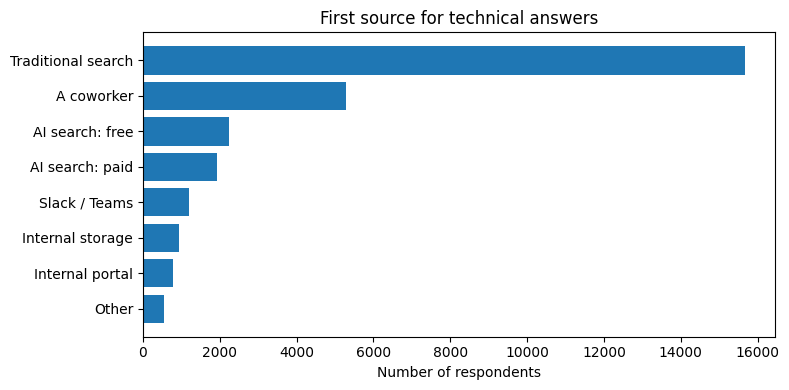

In [ ]:
source_counts = analysis["AnswerSource"].value_counts().sort_values()

plt.figure(figsize=(8, 4))
plt.barh(source_counts.index, source_counts.values)
plt.title("First source for technical answers")
plt.xlabel("Number of respondents")
plt.tight_layout()
plt.show()

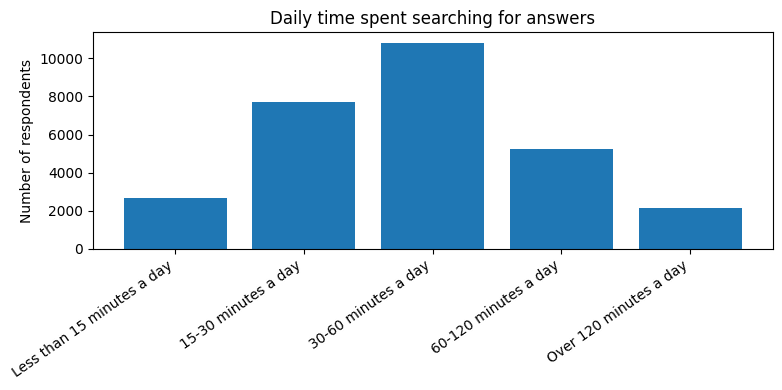

In [ ]:
time_counts = analysis["TimeSearching"].value_counts().reindex(time_order)

plt.figure(figsize=(8, 4))
plt.bar(time_counts.index, time_counts.values)
plt.title("Daily time spent searching for answers")
plt.ylabel("Number of respondents")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

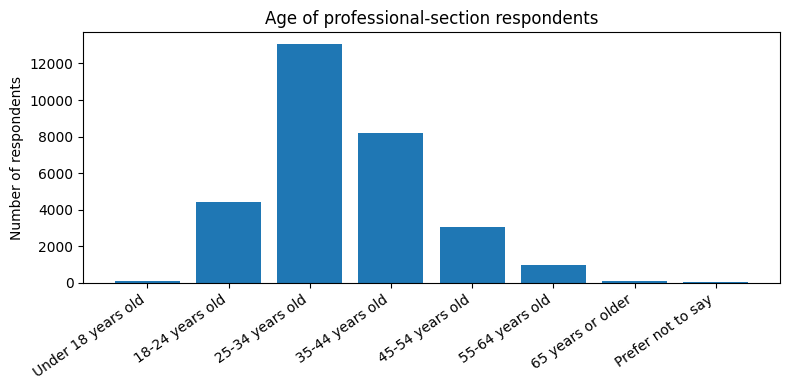

In [ ]:
age_order = [
    "Under 18 years old", "18-24 years old", "25-34 years old",
    "35-44 years old", "45-54 years old", "55-64 years old",
    "65 years or older", "Prefer not to say"
]
age_counts = professional["Age"].value_counts().reindex(age_order)

plt.figure(figsize=(8, 4))
plt.bar(age_counts.index, age_counts.values)
plt.title("Age of professional-section respondents")
plt.ylabel("Number of respondents")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

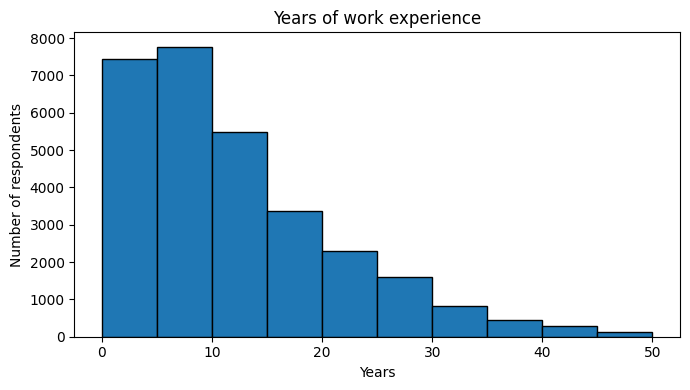

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(professional["WorkExp"].dropna(), bins=10, edgecolor="black")
plt.title("Years of work experience")
plt.xlabel("Years")
plt.ylabel("Number of respondents")
plt.tight_layout()
plt.show()

## Relationship between answer source and search time

In [ ]:
search_percent = pd.crosstab(
    analysis["AnswerSource"],
    analysis["TimeSearching"],
    normalize="index"
) * 100

source_order = analysis["AnswerSource"].value_counts().index
search_percent = search_percent.reindex(index=source_order, columns=time_order)
search_percent.round(1)

TimeSearching,Less than 15 minutes a day,15-30 minutes a day,30-60 minutes a day,60-120 minutes a day,Over 120 minutes a day
AnswerSource,,,,,
Traditional search,8.9,27.2,38.3,18.4,7.2
A coworker,10.8,29.8,36.7,16.2,6.5
AI search: free,7.3,22.3,39.1,21.3,10.0
AI search: paid,7.2,22.1,40.3,21.0,9.4
Slack / Teams,12.1,28.7,37.1,15.9,6.1
Internal storage,9.3,25.9,34.7,19.0,11.0
Internal portal,8.5,28.1,38.0,17.6,7.9
Other,13.4,23.3,34.2,18.8,10.3


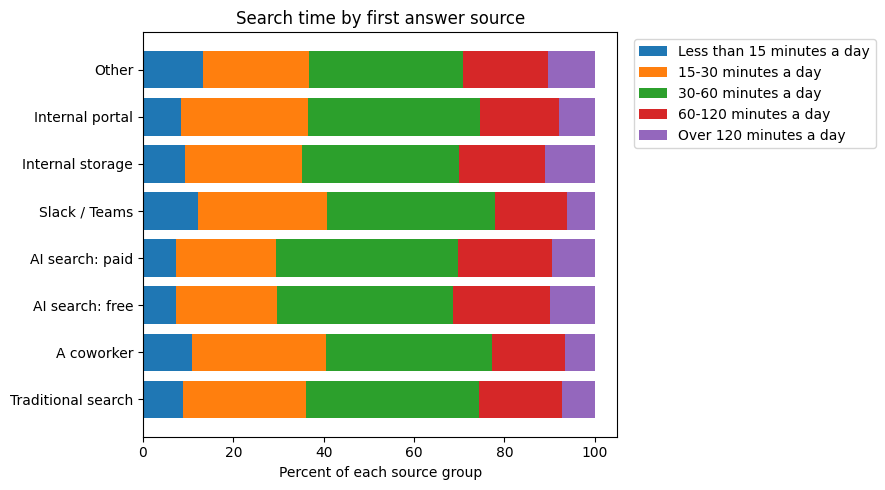

In [ ]:
left = np.zeros(len(search_percent))

plt.figure(figsize=(9, 5))
for category in time_order:
    values = search_percent[category].values
    plt.barh(search_percent.index, values, left=left, label=category)
    left = left + values

plt.title("Search time by first answer source")
plt.xlabel("Percent of each source group")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

To make the comparison easier to read, Ill also calculate the percentage in each group that spends at least 30 minutes searching per day.

In [ ]:
long_search = [
    "30-60 minutes a day",
    "60-120 minutes a day",
    "Over 120 minutes a day"
]

analysis["Search30Plus"] = analysis["TimeSearching"].isin(long_search)

In [ ]:
search_summary = analysis.groupby("AnswerSource").agg(
    Respondents=("ResponseId", "count"),
    Percent30Plus=("Search30Plus", "mean")
)

search_summary["Percent30Plus"] = search_summary["Percent30Plus"] * 100
search_summary.sort_values("Percent30Plus", ascending=False).round(1)

,Respondents,Percent30Plus
AnswerSource,,
AI search: paid,1932,70.7
AI search: free,2230,70.4
Internal storage,933,64.7
Traditional search,15665,63.8
Internal portal,769,63.5
Other,553,63.3
A coworker,5285,59.4
Slack / Teams,1188,59.2


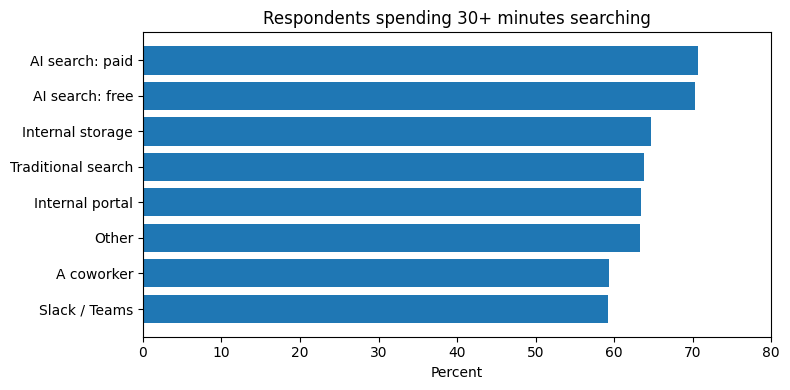

In [ ]:
plot_data = search_summary.sort_values("Percent30Plus")

plt.figure(figsize=(8, 4))
plt.barh(plot_data.index, plot_data["Percent30Plus"])
plt.title("Respondents spending 30+ minutes searching")
plt.xlabel("Percent")
plt.xlim(0, 80)
plt.tight_layout()
plt.show()

## Final data checks

In [ ]:
pd.Series({
    "Rows used in main comparison": len(analysis),
    "Duplicate response IDs": analysis["ResponseId"].duplicated().sum(),
    "Missing answer source": analysis["AnswerSource"].isna().sum(),
    "Missing search time": analysis["TimeSearching"].isna().sum(),
    "Minimum work experience": professional["WorkExp"].min(),
    "Maximum work experience": professional["WorkExp"].max(),
    "Minimum job satisfaction": professional["JobSat"].min(),
    "Maximum job satisfaction": professional["JobSat"].max()
})

Rows used in main comparison    28555.0
Duplicate response IDs              0.0
Missing answer source               0.0
Missing search time                 0.0
Minimum work experience             0.0
Maximum work experience            50.0
Minimum job satisfaction            0.0
Maximum job satisfaction           10.0
dtype: float64

notes

- Traditional search engines and coworkers are the two most common first sources.
- The AI-first groups do not have the lowest reported search time. A larger percentage of both AI groups spends 30 minutes or more searching.
- This is an association in survey data, so I cant just say that AI causes people to spend more time searching.